
# Stock Market Sentiment & Price Impact Analyzer

This notebook implements the analysis described in the project README using the two supplied datasets:

- `event_windows_30d.xls` — ±30-day event windows.
- `merged_event_market_windows.xls` — ±7-day event windows with FinBERT and VADER sentiment scores.

## Project objective

The project studies whether upper-management transitions are associated with short-run movements in Indian stock prices and volatility, and whether surrounding financial-news sentiment amplifies or dampens those effects.

The README specifies:

1. Event-study analysis over a ±30-day window.
2. Log returns and cumulative abnormal returns (CAR).
3. GARCH-X, EGARCH and GJR-GARCH volatility models.
4. ARIMAX and Random Forest forecasting benchmarks.
5. FinBERT and VADER sentiment analysis.
6. Event clustering / shock intensity analysis.
7. Results, limitations and future scope.





## Source alignment

The README states that the study covers NSE-listed/NIFTY 50 companies during 2006–2014, uses daily OHLCV data, a synthetic event dataset, ±7-day sentiment, a ±30-day event study, GARCH-family models, ARIMAX and Random Forest.

The supplied datasets already contain the derived event-window fields needed for most of these steps, so this notebook starts from those files instead of pretending to recreate unavailable raw event/news sources.


In [1]:

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.optimize import minimize

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from statsmodels.tsa.statespace.sarimax import SARIMAX

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

DATA_DIR = Path(".")
EVENT_30D_FILE = DATA_DIR / "event_windows_30d.xls"
MERGED_7D_FILE = DATA_DIR / "merged_event_market_windows.xls"

OUTPUT_DIR = DATA_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

print("Notebook ready.")


Notebook ready.


## Load and validate the supplied datasets

In [2]:

def load_table(path):
    # The supplied files use .xls names but contain CSV text.
    try:
        return pd.read_csv(path)
    except Exception:
        return pd.read_excel(path)

event30 = load_table(EVENT_30D_FILE)
merged7 = load_table(MERGED_7D_FILE)

for name, df in [("event_windows_30d", event30), ("merged_event_market_windows", merged7)]:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df["event_date"] = pd.to_datetime(df["event_date"], errors="coerce")

    print(f"\n{name}")
    print("Shape:", df.shape)
    print("Date range:", df["Date"].min(), "to", df["Date"].max())
    print("Window:", df["window_day"].min(), "to", df["window_day"].max())
    print("Unique tickers:", df["ticker"].nunique())
    print("Unique events:", df[["ticker", "event_date"]].drop_duplicates().shape[0])

print("\n30-day columns:")
print(event30.columns.tolist())

print("\n7-day columns:")
print(merged7.columns.tolist())



event_windows_30d
Shape: (96434, 17)
Date range: 2005-12-13 00:00:00 to 2015-01-29 00:00:00
Window: -30 to 30
Unique tickers: 45
Unique events: 2326

merged_event_market_windows
Shape: (23679, 19)
Date range: 2006-01-05 00:00:00 to 2015-01-06 00:00:00
Window: -7 to 7
Unique tickers: 45
Unique events: 2325

30-day columns:
['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'log_return', 'pct_return', 'volatility_20d', 'volume_zscore', 'ticker', 'event_date', 'window_day', 'clustered', 'shock_intensity', 'combined_sent', 'year']

7-day columns:
['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'log_return', 'pct_return', 'volatility_20d', 'volume_zscore', 'ticker', 'event_date', 'window_day', 'year', 'clustered', 'shock_intensity', 'finbert_sent', 'vader_sent', 'combined_sent']


In [3]:

# Basic data-quality checks
required_30d = [
    "Date", "Close", "Open", "High", "Low", "Volume",
    "log_return", "pct_return", "volatility_20d", "volume_zscore",
    "ticker", "event_date", "window_day", "clustered",
    "shock_intensity", "combined_sent", "year"
]

required_7d = required_30d + ["finbert_sent", "vader_sent"]

print("Missing required 30-day columns:", sorted(set(required_30d) - set(event30.columns)))
print("Missing required 7-day columns:", sorted(set(required_7d) - set(merged7.columns)))

print("\nMissing values in 30-day dataset:")
display(event30[required_30d].isna().sum().sort_values(ascending=False).to_frame("missing"))

print("\nDuplicate ticker/event/date rows in 30-day dataset:",
      event30.duplicated(["ticker", "event_date", "Date"]).sum())

print("\nShock intensity counts:")
display(event30["shock_intensity"].value_counts(dropna=False).to_frame("count"))

print("\nClustered-event flag:")
display(event30["clustered"].value_counts(dropna=False).to_frame("count"))


Missing required 30-day columns: []
Missing required 7-day columns: []

Missing values in 30-day dataset:


,missing
volume_zscore,731
volatility_20d,75
pct_return,3
log_return,3
Date,0
Low,0
High,0
Open,0
Close,0
Volume,0



Duplicate ticker/event/date rows in 30-day dataset: 1025

Shock intensity counts:


,count
shock_intensity,
Low,80039
High,16395



Clustered-event flag:


,count
clustered,
0,80039
1,16395



### Why duplicate event-window rows can exist

The same stock/date can appear in overlapping event windows. This is not automatically an error: the surrounding sentiment or event context can differ between two nearby events.

For event-level analysis we therefore keep the event identifier `(ticker, event_date)` rather than globally deduplicating the dataset.


## 2. Descriptive analysis

In [4]:

desc_cols = [
    "Close", "Volume", "log_return", "pct_return",
    "volatility_20d", "volume_zscore", "combined_sent"
]

display(event30[desc_cols].describe().T)

event_summary = (
    event30.groupby(["ticker", "event_date"])
    .agg(
        clustered=("clustered", "max"),
        shock_intensity=("shock_intensity", "first"),
        mean_sentiment=("combined_sent", "mean"),
        event_day_return=("log_return", lambda x: x[event30.loc[x.index, "window_day"].eq(0)].mean())
    )
    .reset_index()
)

print("Event-level observations:", len(event_summary))
display(event_summary.head())


,count,mean,std,min,25%,50%,75%,max
Close,96434.0,3.688657e+02,6.953396e+02,0.489266,86.480330,1.805774e+02,3.749812e+02,9.008610e+03
Volume,96434.0,6.583764e+06,1.313449e+07,0.000000,574790.000000,2.261530e+06,7.165884e+06,5.087530e+08
log_return,96431.0,9.693246e-04,2.329385e-02,-1.441124,-0.010549,2.831689e-04,1.195242e-02,2.905092e-01
pct_return,96431.0,1.234528e-03,2.274522e-02,-0.763338,-0.010494,2.832090e-04,1.202414e-02,3.371081e-01
volatility_20d,96359.0,2.037263e-02,1.078074e-02,0.000000,0.014074,1.808887e-02,2.391805e-02,3.228344e-01
volume_zscore,95703.0,-3.834813e-03,1.038892e+00,-3.472718,-0.655954,-2.725231e-01,3.741812e-01,5.294651e+00
combined_sent,96434.0,-1.400352e-01,2.172406e-01,-0.967479,-0.263001,-1.073168e-01,8.707703e-03,3.748344e-01


Event-level observations: 2326


,ticker,event_date,clustered,shock_intensity,mean_sentiment,event_day_return
0,ADANIENT.NS,2006-03-05,0,Low,-0.064339,NaN
1,ADANIENT.NS,2007-05-26,0,Low,-0.039863,NaN
2,ADANIENT.NS,2007-08-31,0,Low,0.011822,0.026660
3,ADANIENT.NS,2008-02-16,0,Low,-0.062482,NaN
4,ADANIENT.NS,2008-06-02,0,Low,0.107904,0.003153


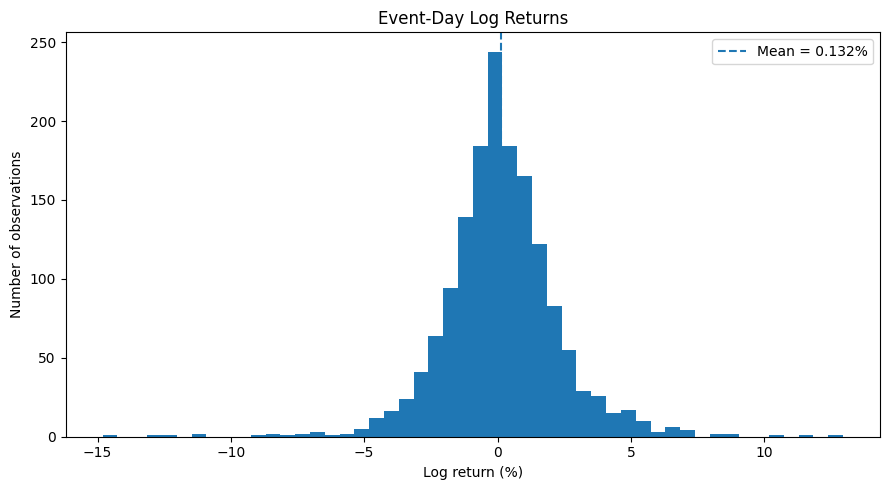

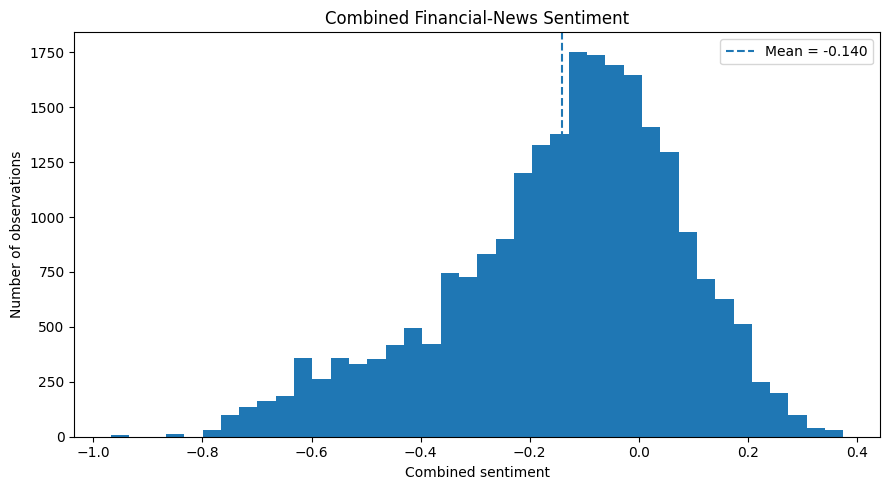

In [5]:

# Event-day return and sentiment distributions
fig, ax = plt.subplots(figsize=(9, 5))
event_day = event30.loc[event30["window_day"].eq(0), "log_return"].dropna() * 100
ax.hist(event_day, bins=50)
ax.axvline(event_day.mean(), linestyle="--", label=f"Mean = {event_day.mean():.3f}%")
ax.set_title("Event-Day Log Returns")
ax.set_xlabel("Log return (%)")
ax.set_ylabel("Number of observations")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(merged7["combined_sent"].dropna(), bins=40)
ax.axvline(merged7["combined_sent"].mean(), linestyle="--",
           label=f"Mean = {merged7['combined_sent'].mean():.3f}")
ax.set_title("Combined Financial-News Sentiment")
ax.set_xlabel("Combined sentiment")
ax.set_ylabel("Number of observations")
ax.legend()
plt.tight_layout()
plt.show()



## Event-study analysis

The README specifies a ±30-day event window.

For each `(ticker, event_date)`:

- `log_return_t = ln(P_t / P_{t-1})`
- Expected return is estimated from the event-specific pre-event window `[-30, -11]`.
- `AR_t = R_t - E[R_t]`
- `CAR(a,b) = sum(AR_t)` for the requested event window.

Because the supplied data do **not** include a market-index return, the resulting CAR is a **pre-event mean-adjusted CAR proxy**, not a conventional market-model CAR.

Raw cumulative returns are also reported separately.


In [6]:

def build_event_study(df, estimation_window=(-30, -11), event_windows=((0, 1), (0, 5))):
    keys = ["ticker", "event_date"]

    est = (
        df[df["window_day"].between(*estimation_window)]
        .groupby(keys)["log_return"]
        .mean()
        .rename("expected_return")
    )

    x = df.merge(est, on=keys, how="left")
    x["abnormal_return"] = x["log_return"] - x["expected_return"]

    rows = []
    for (ticker, event_date), g in x.groupby(keys):
        row = {"ticker": ticker, "event_date": event_date}
        row["estimation_mean_return"] = g["expected_return"].iloc[0]

        for a, b in event_windows:
            w = g[g["window_day"].between(a, b)]
            car = w["abnormal_return"].sum()
            raw_cum = np.exp(w["log_return"].sum()) - 1

            row[f"CAR_proxy_{a}_{b}"] = car
            row[f"raw_cum_return_{a}_{b}"] = raw_cum
            row[f"n_obs_{a}_{b}"] = len(w)

        rows.append(row)

    return x, pd.DataFrame(rows)

event_study_long, event_study = build_event_study(event30)

display(event_study.head())

for col in ["CAR_proxy_0_1", "CAR_proxy_0_5", "raw_cum_return_0_1", "raw_cum_return_0_5"]:
    s = event_study[col].dropna()
    t = stats.ttest_1samp(s, 0)
    print(f"{col}: n={len(s):,}, mean={s.mean():.4%}, median={s.median():.4%}, t={t.statistic:.3f}, p={t.pvalue:.4f}")


,ticker,event_date,estimation_mean_return,CAR_proxy_0_1,raw_cum_return_0_1,n_obs_0_1,CAR_proxy_0_5,raw_cum_return_0_5,n_obs_0_5
0,ADANIENT.NS,2006-03-05,-0.000066,-0.005179,-0.005231,1,-0.015487,-0.015693,5
1,ADANIENT.NS,2007-05-26,0.000642,0.000000,0.000000,0,-0.014632,-0.011990,4
2,ADANIENT.NS,2007-08-31,0.000104,0.026556,0.027019,1,0.053777,0.055689,4
3,ADANIENT.NS,2008-02-16,-0.015855,0.000000,0.000000,0,0.026592,-0.036158,4
4,ADANIENT.NS,2008-06-02,-0.000928,-0.041646,-0.042569,2,-0.074518,-0.076107,5


CAR_proxy_0_1: n=2,326, mean=0.0450%, median=0.0000%, t=0.767, p=0.4430
CAR_proxy_0_5: n=2,326, mean=-0.0774%, median=-0.1120%, t=-0.722, p=0.4705
raw_cum_return_0_1: n=2,326, mean=0.1724%, median=0.0000%, t=3.126, p=0.0018
raw_cum_return_0_5: n=2,326, mean=0.3573%, median=0.0996%, t=3.853, p=0.0001


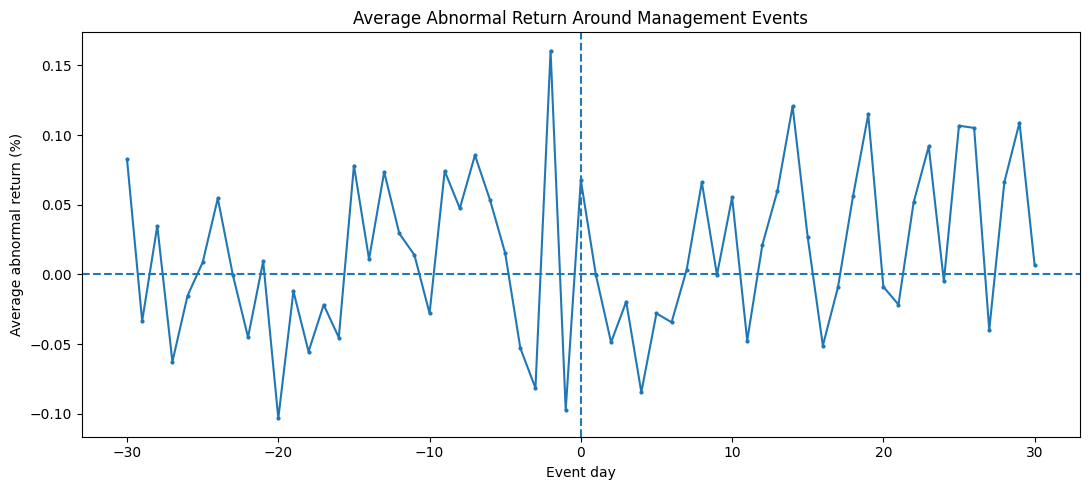

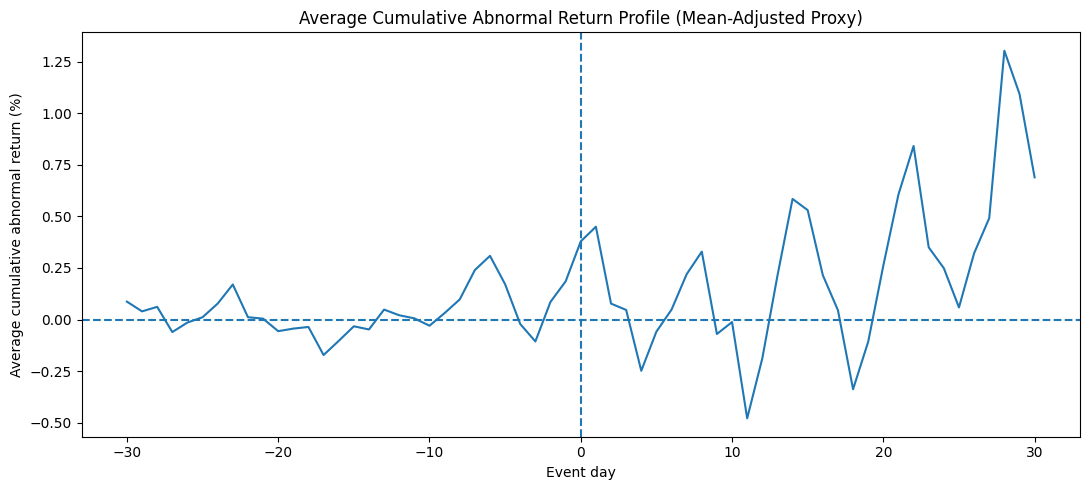

In [7]:

# Average abnormal-return profile from day -30 to +30
aar = (
    event_study_long.groupby("window_day")["abnormal_return"]
    .mean()
    .mul(100)
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(aar.index, aar.values, marker="o", markersize=2)
ax.axhline(0, linestyle="--")
ax.axvline(0, linestyle="--")
ax.set_title("Average Abnormal Return Around Management Events")
ax.set_xlabel("Event day")
ax.set_ylabel("Average abnormal return (%)")
plt.tight_layout()
plt.show()

# Average cumulative abnormal return profile
car_profile = (
    event_study_long.sort_values(["ticker", "event_date", "window_day"])
    .groupby(["ticker", "event_date"])["abnormal_return"]
    .cumsum()
    .groupby(event_study_long.sort_values(["ticker", "event_date", "window_day"])["window_day"])
    .mean()
    .mul(100)
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(car_profile.index, car_profile.values)
ax.axhline(0, linestyle="--")
ax.axvline(0, linestyle="--")
ax.set_title("Average Cumulative Abnormal Return Profile (Mean-Adjusted Proxy)")
ax.set_xlabel("Event day")
ax.set_ylabel("Average cumulative abnormal return (%)")
plt.tight_layout()
plt.show()



### Optional true market-model CAR

If NIFTY 50 daily returns are available, the standard event-study route is:

`R_it = alpha_i + beta_i R_mt + epsilon_it`

followed by:

`AR_it = R_it - (alpha_hat_i + beta_hat_i R_mt)`

and then:

`CAR_i(a,b) = sum AR_it`.

The next cell shows how to download `^NSEI` with `yfinance`. It is intentionally optional so the supplied datasets remain sufficient to run the notebook.


In [8]:

# OPTIONAL: true market-model event study using NIFTY 50.
# Set DOWNLOAD_MARKET_DATA=True only when internet access and yfinance are available.

DOWNLOAD_MARKET_DATA = False

if DOWNLOAD_MARKET_DATA:
    import yfinance as yf

    start = event30["Date"].min() - pd.Timedelta(days=60)
    end = event30["Date"].max() + pd.Timedelta(days=5)

    nifty = yf.download("^NSEI", start=start, end=end, auto_adjust=False, progress=False)
    nifty = nifty.reset_index()

    # Depending on yfinance version, flatten a MultiIndex if present.
    if isinstance(nifty.columns, pd.MultiIndex):
        nifty.columns = [c[0] if isinstance(c, tuple) else c for c in nifty.columns]

    nifty["market_log_return"] = np.log(nifty["Close"] / nifty["Close"].shift(1))
    nifty = nifty[["Date", "market_log_return"]].dropna()

    display(nifty.head())
else:
    print("Skipped optional NIFTY 50 download.")


Skipped optional NIFTY 50 download.


## Sentiment analysis: FinBERT vs VADER

Correlation matrix:


,finbert_sent,vader_sent,combined_sent
finbert_sent,1.000000,0.318875,0.859167
vader_sent,0.318875,1.000000,0.758950
combined_sent,0.859167,0.758950,1.000000


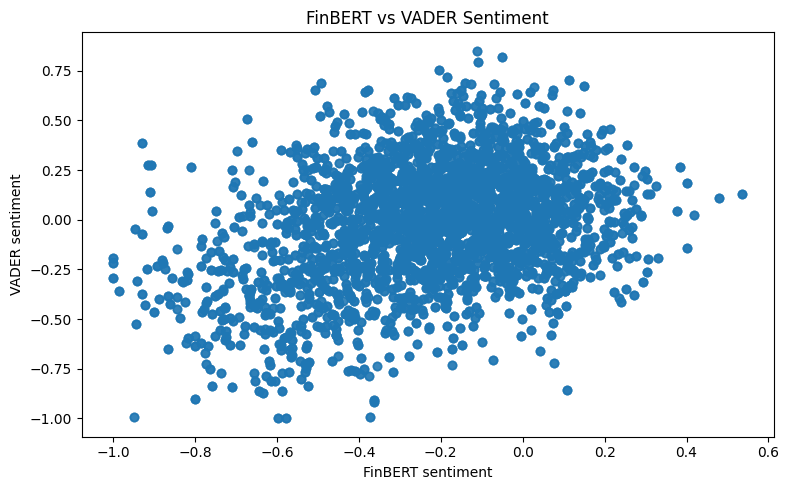

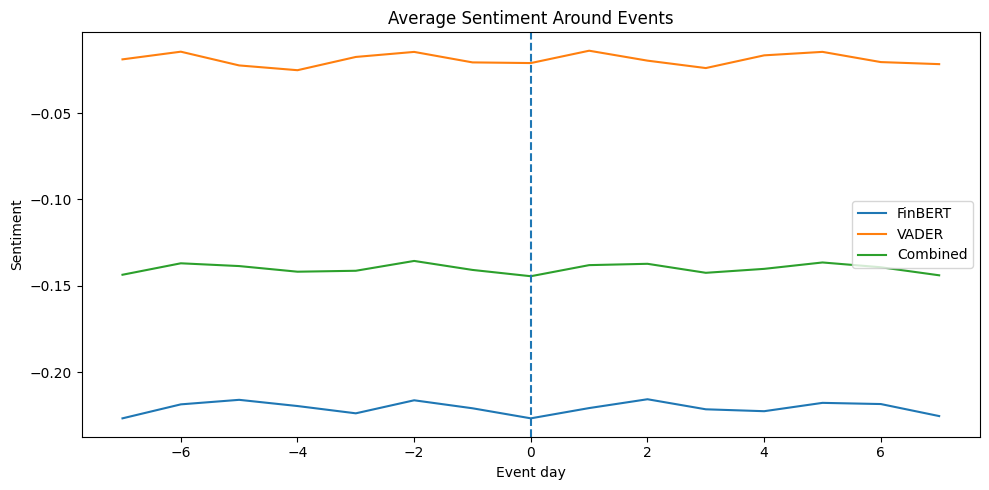

In [9]:

sent = merged7[["finbert_sent", "vader_sent", "combined_sent"]].dropna()

print("Correlation matrix:")
display(sent.corr())

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sent["finbert_sent"], sent["vader_sent"], alpha=0.25)
ax.set_xlabel("FinBERT sentiment")
ax.set_ylabel("VADER sentiment")
ax.set_title("FinBERT vs VADER Sentiment")
plt.tight_layout()
plt.show()

# Sentiment by event day
sent_day = (
    merged7.groupby("window_day")[["finbert_sent", "vader_sent", "combined_sent"]]
    .mean()
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sent_day.index, sent_day["finbert_sent"], label="FinBERT")
ax.plot(sent_day.index, sent_day["vader_sent"], label="VADER")
ax.plot(sent_day.index, sent_day["combined_sent"], label="Combined")
ax.axvline(0, linestyle="--")
ax.set_title("Average Sentiment Around Events")
ax.set_xlabel("Event day")
ax.set_ylabel("Sentiment")
ax.legend()
plt.tight_layout()
plt.show()



### Raw-news limitation

The supplied datasets contain **precomputed sentiment scores**, but they do not contain raw news article text. Therefore the notebook does not pretend to rerun FinBERT or VADER inference. The analysis above uses the stored scores exactly as supplied.

If raw news text is added later, a separate NLP cell can run FinBERT and VADER directly.


## Event clustering and shock-intensity analysis

In [10]:

# Compare clustered vs non-clustered events
cluster_event = event_study.merge(
    event_summary[["ticker", "event_date", "clustered", "shock_intensity", "mean_sentiment"]],
    on=["ticker", "event_date"],
    how="left"
)

metrics = ["CAR_proxy_0_1", "CAR_proxy_0_5", "raw_cum_return_0_1", "raw_cum_return_0_5"]

cluster_table = cluster_event.groupby("clustered")[metrics].agg(["count", "mean", "median"])
display(cluster_table)

shock_table = cluster_event.groupby("shock_intensity")[metrics].agg(["count", "mean", "median"])
display(shock_table)


CAR_proxy_0_1                  CAR_proxy_0_5                     raw_cum_return_0_1                  raw_cum_return_0_5  \
                  count      mean median         count      mean    median              count      mean median              count   
clustered                                                                                                                           
0                  1926  0.000890    0.0          1926 -0.000431 -0.001171               1926  0.002032    0.0               1926   
1                   400 -0.001665    0.0           400 -0.002424 -0.001001                400  0.000243    0.0                400   

                               
               mean    median  
clustered                      
0          0.003761  0.001181  
1          0.002670  0.000770

CAR_proxy_0_1                  CAR_proxy_0_5                     raw_cum_return_0_1                  raw_cum_return_0_5  \
                        count      mean median         count      mean    median              count      mean median              count   
shock_intensity                                                                                                                           
High                      400 -0.001665    0.0           400 -0.002424 -0.001001                400  0.000243    0.0                400   
Low                      1926  0.000890    0.0          1926 -0.000431 -0.001171               1926  0.002032    0.0               1926   

                                     
                     mean    median  
shock_intensity                      
High             0.002670  0.000770  
Low              0.003761  0.001181

,count,mean,median,std,mean_pct
clustered,,,,,
0,1296,0.001785,0.000948,0.022684,0.178485
1,270,-0.000920,-0.002287,0.019469,-0.092008


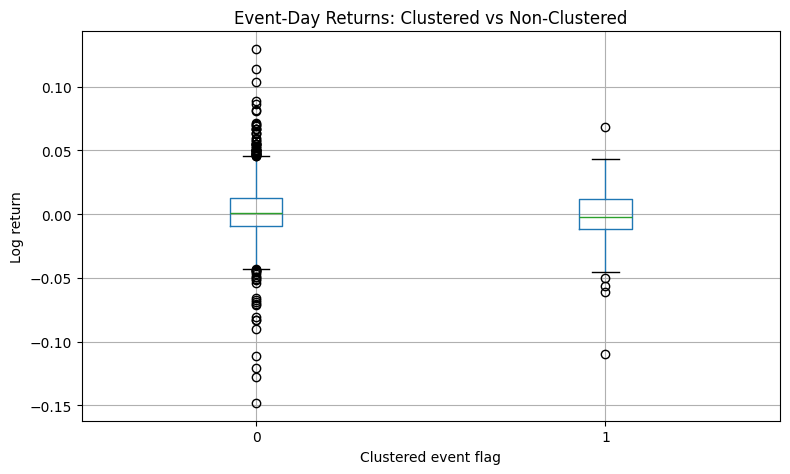

In [11]:

# Event-day return by cluster
event_day = event30[event30["window_day"].eq(0)].copy()

cluster_day = (
    event_day.groupby("clustered")["log_return"]
    .agg(["count", "mean", "median", "std"])
    .assign(mean_pct=lambda x: x["mean"] * 100)
)

display(cluster_day)

fig, ax = plt.subplots(figsize=(8, 5))
event_day.boxplot(column="log_return", by="clustered", ax=ax)
plt.suptitle("")
ax.set_title("Event-Day Returns: Clustered vs Non-Clustered")
ax.set_xlabel("Clustered event flag")
ax.set_ylabel("Log return")
plt.tight_layout()
plt.show()



##  Prepare a pooled daily event-window series for volatility models

The supplied data are an event-window panel rather than one uninterrupted market time series.

For a reproducible pooled benchmark, observations are aggregated by calendar date:

- mean log return across available event-window stocks;
- mean combined sentiment;
- event-day dummy = 1 if any event occurs on that date;
- mean 20-day volatility;
- number of stocks represented.

This is a **pooled event-window modelling sample**, not a single-stock continuous GARCH series. That distinction matters when interpreting the coefficients.


In [12]:

panel = (
    event30.groupby("Date")
    .agg(
        log_return=("log_return", "mean"),
        combined_sent=("combined_sent", "mean"),
        event_dummy=("window_day", lambda s: int((s == 0).any())),
        event_obs=("ticker", "nunique"),
        volatility_20d=("volatility_20d", "mean"),
    )
    .sort_index()
    .dropna()
    .reset_index()
)

panel["sent_z"] = (
    (panel["combined_sent"] - panel["combined_sent"].mean())
    / panel["combined_sent"].std()
)

print(panel.shape)
display(panel.head())


(2251, 7)


,Date,log_return,combined_sent,event_dummy,event_obs,volatility_20d,sent_z
0,2005-12-13,0.011740,-0.339468,0,1,0.019547,-4.093893
1,2005-12-14,-0.004786,-0.339468,0,1,0.019333,-4.093893
2,2005-12-15,-0.002669,-0.339468,0,1,0.019414,-4.093893
3,2005-12-16,0.013941,-0.120389,0,2,0.017761,0.221850
4,2005-12-19,0.014857,-0.242245,0,3,0.018985,-2.178663



## GARCH-X, EGARCH and GJR-GARCH

The README specifies:

- **GARCH-X:** sentiment and event-day shocks enter the mean/variance specification.
- **EGARCH:** captures asymmetric volatility.
- **GJR-GARCH:** captures leverage effects from negative shocks.

The environment may not have the optional `arch` package, so the notebook implements compact Gaussian maximum-likelihood versions directly with `scipy.optimize`.

Returns are multiplied by 100 for numerical stability.


In [13]:

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -50, 50)))


def fit_garch_x(y, sent, event):
    y = np.asarray(y, dtype=float)
    sent = np.asarray(sent, dtype=float)
    event = np.asarray(event, dtype=float)
    n = len(y)
    init_var = max(np.var(y), 1e-8)

    def unpack(th):
        omega = np.exp(th[0])
        alpha = 0.98 * sigmoid(th[1])
        beta = (0.98 - alpha) * sigmoid(th[2])
        b_sent, b_event = th[3], th[4]
        delta, eta = np.exp(th[5]), np.exp(th[6])
        mu = th[7]
        return omega, alpha, beta, b_sent, b_event, delta, eta, mu

    def nll(th):
        omega, alpha, beta, b_sent, b_event, delta, eta, mu = unpack(th)
        eps = y - (mu + b_sent * sent + b_event * event)

        h = np.empty(n)
        h[0] = init_var

        for t in range(1, n):
            h[t] = (
                omega
                + alpha * eps[t - 1] ** 2
                + beta * h[t - 1]
                + delta * abs(sent[t])
                + eta * event[t]
            )
            if (not np.isfinite(h[t])) or h[t] <= 0 or h[t] > 1e8:
                return 1e50

        return 0.5 * np.sum(np.log(2 * np.pi) + np.log(h) + eps ** 2 / h)

    x0 = np.array([
        np.log(max(init_var * 0.05, 1e-8)),
        -2, 1, 0, 0, -3, -3, np.mean(y)
    ])

    res = minimize(nll, x0, method="L-BFGS-B", options={"maxiter": 600})
    return res, unpack(res.x)


def fit_egarch_x(y, sent, event):
    y = np.asarray(y, dtype=float)
    sent = np.asarray(sent, dtype=float)
    event = np.asarray(event, dtype=float)
    n = len(y)

    def unpack(th):
        omega = th[0]
        beta = np.tanh(th[1])
        alpha, gamma = th[2], th[3]
        b_sent, b_event = th[4], th[5]
        delta, eta = np.exp(th[6]), np.exp(th[7])
        mu = th[8]
        return omega, beta, alpha, gamma, b_sent, b_event, delta, eta, mu

    def nll(th):
        omega, beta, alpha, gamma, b_sent, b_event, delta, eta, mu = unpack(th)
        eps = y - (mu + b_sent * sent + b_event * event)

        logh = np.empty(n)
        logh[0] = np.log(max(np.var(y), 1e-8))

        for t in range(1, n):
            z = eps[t - 1] / np.sqrt(np.exp(logh[t - 1]))
            logh[t] = (
                omega
                + beta * logh[t - 1]
                + alpha * (abs(z) - np.sqrt(2 / np.pi))
                + gamma * z
                + delta * abs(sent[t])
                + eta * event[t]
            )
            if (not np.isfinite(logh[t])) or logh[t] > 30 or logh[t] < -30:
                return 1e50

        h = np.exp(logh)
        return 0.5 * np.sum(np.log(2 * np.pi) + logh + eps ** 2 / h)

    x0 = np.array([-0.1, 1, 0.1, -0.1, 0, 0, -3, -3, np.mean(y)])
    res = minimize(nll, x0, method="L-BFGS-B", options={"maxiter": 600})
    return res, unpack(res.x)


def fit_gjr_x(y, sent, event):
    y = np.asarray(y, dtype=float)
    sent = np.asarray(sent, dtype=float)
    event = np.asarray(event, dtype=float)
    n = len(y)
    init_var = max(np.var(y), 1e-8)

    def unpack(th):
        omega = np.exp(th[0])
        alpha = 0.5 * sigmoid(th[1])
        gamma = 0.5 * sigmoid(th[2])
        beta = (0.99 - alpha - 0.5 * gamma) * sigmoid(th[3])
        b_sent, b_event = th[4], th[5]
        delta, eta = np.exp(th[6]), np.exp(th[7])
        mu = th[8]
        return omega, alpha, gamma, beta, b_sent, b_event, delta, eta, mu

    def nll(th):
        omega, alpha, gamma, beta, b_sent, b_event, delta, eta, mu = unpack(th)
        eps = y - (mu + b_sent * sent + b_event * event)

        h = np.empty(n)
        h[0] = init_var

        for t in range(1, n):
            negative = float(eps[t - 1] < 0)
            h[t] = (
                omega
                + alpha * eps[t - 1] ** 2
                + gamma * eps[t - 1] ** 2 * negative
                + beta * h[t - 1]
                + delta * abs(sent[t])
                + eta * event[t]
            )
            if (not np.isfinite(h[t])) or h[t] <= 0 or h[t] > 1e8:
                return 1e50

        return 0.5 * np.sum(np.log(2 * np.pi) + np.log(h) + eps ** 2 / h)

    x0 = np.array([
        np.log(max(init_var * 0.05, 1e-8)),
        -2, -2, 1, 0, 0, -3, -3, np.mean(y)
    ])

    res = minimize(nll, x0, method="L-BFGS-B", options={"maxiter": 600})
    return res, unpack(res.x)


In [14]:

y = panel["log_return"].to_numpy() * 100
s = panel["sent_z"].to_numpy()
ev = panel["event_dummy"].to_numpy()

garch_res, garch_p = fit_garch_x(y, s, ev)
egarch_res, egarch_p = fit_egarch_x(y, s, ev)
gjr_res, gjr_p = fit_gjr_x(y, s, ev)

garch_names = ["omega", "alpha", "beta", "sent_mean", "event_mean", "sent_variance", "event_variance", "mu"]
egarch_names = ["omega", "beta", "alpha", "gamma", "sent_mean", "event_mean", "sent_variance", "event_variance", "mu"]
gjr_names = ["omega", "alpha", "gamma", "beta", "sent_mean", "event_mean", "sent_variance", "event_variance", "mu"]

garch_table = pd.DataFrame({"parameter": garch_names, "estimate": garch_p})
egarch_table = pd.DataFrame({"parameter": egarch_names, "estimate": egarch_p})
gjr_table = pd.DataFrame({"parameter": gjr_names, "estimate": gjr_p})

print("GARCH-X success:", garch_res.success, "| message:", garch_res.message)
display(garch_table)

print("EGARCH success:", egarch_res.success, "| message:", egarch_res.message)
display(egarch_table)

print("GJR-GARCH success:", gjr_res.success, "| message:", gjr_res.message)
display(gjr_table)

model_fit = pd.DataFrame({
    "model": ["GARCH-X", "EGARCH", "GJR-GARCH"],
    "negative_log_likelihood": [garch_res.fun, egarch_res.fun, gjr_res.fun],
    "optimizer_success": [garch_res.success, egarch_res.success, gjr_res.success]
})
display(model_fit)


GARCH-X success: True | message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


,parameter,estimate
0,omega,3.211365e-02
1,alpha,1.110213e-01
2,beta,8.689787e-01
3,sent_mean,1.685673e-02
4,event_mean,-5.276838e-02
5,sent_variance,1.016439e-02
6,event_variance,3.762564e-07
7,mu,1.462302e-01


EGARCH success: True | message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


,parameter,estimate
0,omega,1.582507e-02
1,beta,9.791062e-01
2,alpha,2.109055e-01
3,gamma,-4.927567e-02
4,sent_mean,3.127786e-02
5,event_mean,-7.611926e-02
6,sent_variance,1.707175e-14
7,event_variance,5.585374e-07
8,mu,1.363086e-01


GJR-GARCH success: True | message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


,parameter,estimate
0,omega,0.023765
1,alpha,0.078828
2,gamma,0.058540
3,beta,0.881829
4,sent_mean,0.019602
5,event_mean,-0.062195
6,sent_variance,0.007924
7,event_variance,0.000015
8,mu,0.132505


,model,negative_log_likelihood,optimizer_success
0,GARCH-X,3668.439431,True
1,EGARCH,3665.839047,True
2,GJR-GARCH,3662.574111,True



### Interpreting the asymmetric models

For EGARCH, the `gamma` term captures sign asymmetry in shocks.

For GJR-GARCH, the `gamma` term measures the additional variance response to negative shocks.

A positive leverage/asymmetry coefficient is consistent with negative shocks producing larger volatility responses, but coefficient significance should be assessed with a dedicated inferential implementation before making a formal statistical claim.


## ARIMAX forecasting

ARIMAX RMSE: 0.009480731394239859
ARIMAX MAE : 0.0070999372408009805


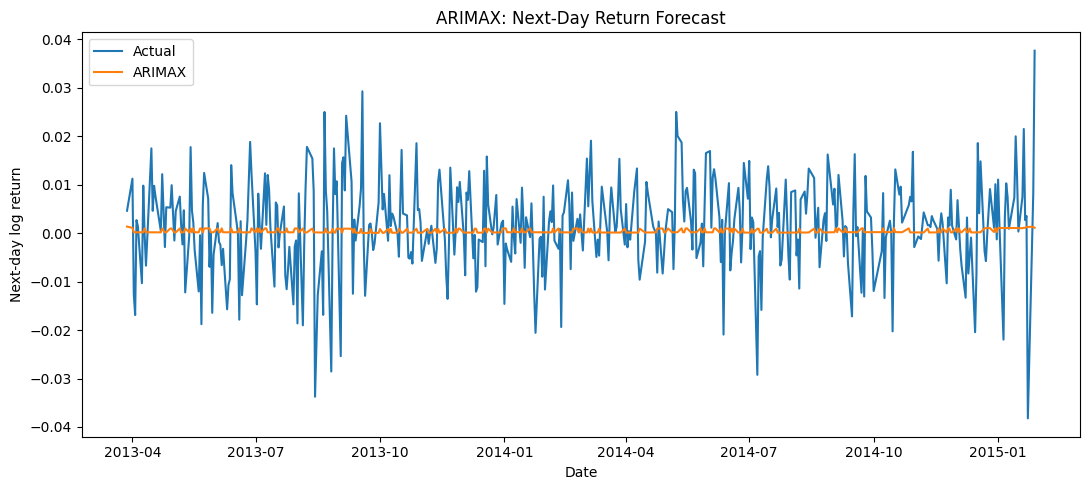

In [15]:

# Predict next-day pooled return using lagged sentiment/event information.
ar = panel.copy()
ar["target_next_return"] = ar["log_return"].shift(-1)

ar["sent_lag1"] = ar["combined_sent"].shift(1)
ar["event_lag1"] = ar["event_dummy"].shift(1)

ar = ar.dropna().reset_index(drop=True)

split = int(len(ar) * 0.80)
train = ar.iloc[:split]
test = ar.iloc[split:]

exog_cols = ["sent_lag1", "event_lag1"]

arimax = SARIMAX(
    train["target_next_return"],
    exog=train[exog_cols],
    order=(1, 0, 1),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False,
)

arimax_fit = arimax.fit(disp=False)
arimax_pred = arimax_fit.forecast(
    steps=len(test),
    exog=test[exog_cols]
)

arimax_rmse = np.sqrt(mean_squared_error(test["target_next_return"], arimax_pred))
arimax_mae = mean_absolute_error(test["target_next_return"], arimax_pred)

print("ARIMAX RMSE:", arimax_rmse)
print("ARIMAX MAE :", arimax_mae)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(test["Date"], test["target_next_return"].values, label="Actual")
ax.plot(test["Date"], np.asarray(arimax_pred), label="ARIMAX")
ax.set_title("ARIMAX: Next-Day Return Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Next-day log return")
ax.legend()
plt.tight_layout()
plt.show()


## Random Forest regression benchmark

,metric,value
0,RMSE,0.000707
1,MAE,0.000539
2,R2,0.945174


,importance
vol_lag1,0.987141
sent_lag1,0.004295
return_lag2,0.002876
event_obs,0.002822
return_lag1,0.002664
event_lag1,0.000202


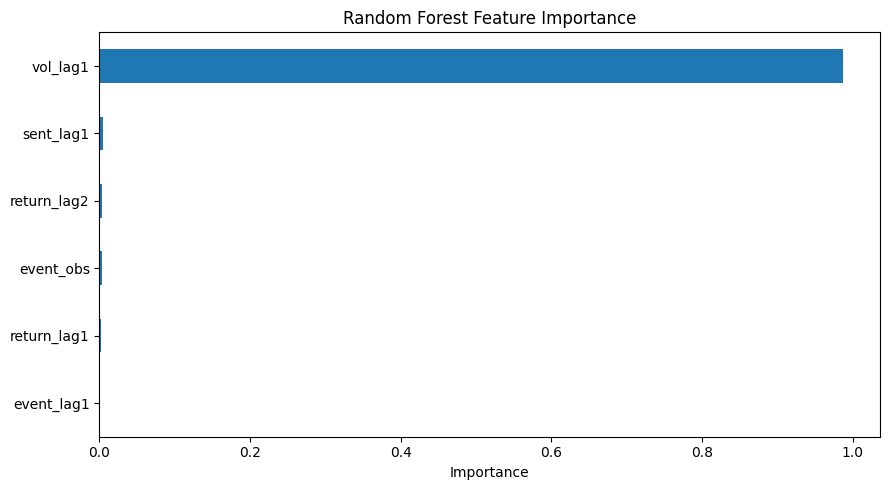

In [16]:

rf = panel.copy()

rf["target_next_volatility"] = rf["volatility_20d"].shift(-1)
rf["return_lag1"] = rf["log_return"].shift(1)
rf["return_lag2"] = rf["log_return"].shift(2)
rf["sent_lag1"] = rf["combined_sent"].shift(1)
rf["event_lag1"] = rf["event_dummy"].shift(1)
rf["vol_lag1"] = rf["volatility_20d"].shift(1)

features = [
    "return_lag1", "return_lag2",
    "sent_lag1", "event_lag1", "vol_lag1",
    "event_obs"
]

rf = rf.dropna().reset_index(drop=True)

split = int(len(rf) * 0.80)
rf_train = rf.iloc[:split]
rf_test = rf.iloc[split:]

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

model.fit(rf_train[features], rf_train["target_next_volatility"])
rf_pred = model.predict(rf_test[features])

rf_rmse = np.sqrt(mean_squared_error(rf_test["target_next_volatility"], rf_pred))
rf_mae = mean_absolute_error(rf_test["target_next_volatility"], rf_pred)
rf_r2 = r2_score(rf_test["target_next_volatility"], rf_pred)

rf_metrics = pd.DataFrame({
    "metric": ["RMSE", "MAE", "R2"],
    "value": [rf_rmse, rf_mae, rf_r2]
})

display(rf_metrics)

importance = (
    pd.Series(model.feature_importances_, index=features)
    .sort_values(ascending=False)
)

display(importance.to_frame("importance"))

fig, ax = plt.subplots(figsize=(9, 5))
importance.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Random Forest Feature Importance")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()


In [17]:

# Compute a compact empirical summary from the supplied data
summary_rows = []

for col, label in [
    ("raw_cum_return_0_1", "Raw cumulative return (0,1)"),
    ("raw_cum_return_0_5", "Raw cumulative return (0,5)"),
    ("CAR_proxy_0_1", "Pre-event mean-adjusted CAR proxy (0,1)"),
    ("CAR_proxy_0_5", "Pre-event mean-adjusted CAR proxy (0,5)")
]:
    s = event_study[col].dropna()
    summary_rows.append({
        "metric": label,
        "n_events": len(s),
        "mean": s.mean(),
        "median": s.median(),
        "std": s.std()
    })

empirical_summary = pd.DataFrame(summary_rows)
display(empirical_summary)

print("\nREADME headline values for reference only:")
readme_values = pd.DataFrame({
    "metric": [
        "CAR (0,1)", "CAR (0,5)", "Max volatility spike",
        "GARCH-X event-day effect", "Clustered resignations"
    ],
    "README_value": ["-4.89%", "-2.60%", "0.11", "-3.38% return", "+6% to +11%"]
})
display(readme_values)


,metric,n_events,mean,median,std
0,"Raw cumulative return (0,1)",2326,0.001724,0.000000,0.026600
1,"Raw cumulative return (0,5)",2326,0.003573,0.000996,0.044724
2,"Pre-event mean-adjusted CAR proxy (0,1)",2326,0.000450,0.000000,0.028312
3,"Pre-event mean-adjusted CAR proxy (0,5)",2326,-0.000774,-0.001120,0.051705



README headline values for reference only:


,metric,README_value
0,"CAR (0,1)",-4.89%
1,"CAR (0,5)",-2.60%
2,Max volatility spike,0.11
3,GARCH-X event-day effect,-3.38% return
4,Clustered resignations,+6% to +11%


In [18]:

event_study.to_csv(OUTPUT_DIR / "event_study_results.csv", index=False)
event_summary.to_csv(OUTPUT_DIR / "event_summary.csv", index=False)
empirical_summary.to_csv(OUTPUT_DIR / "empirical_summary.csv", index=False)
model_fit.to_csv(OUTPUT_DIR / "volatility_model_fit.csv", index=False)
rf_metrics.to_csv(OUTPUT_DIR / "random_forest_metrics.csv", index=False)

print("Saved outputs:")
for p in sorted(OUTPUT_DIR.glob("*.csv")):
    print(" -", p)


Saved outputs:
 - outputs/empirical_summary.csv
 - outputs/event_study_results.csv
 - outputs/event_summary.csv
 - outputs/random_forest_metrics.csv
 - outputs/volatility_model_fit.csv



## Limitations and future scope

### Limitations reflected in the README and current data

- The event dataset is synthetic rather than raw MCA-21 filings.
- Historical news text is not included in the supplied files, so FinBERT/VADER scores cannot be regenerated from raw articles here.
- A market benchmark return series is not included, so the main event-study CAR is a pre-event mean-adjusted proxy.
- The volatility models use a pooled event-window series rather than a continuous single-stock time series.
- Short-window forecasting can be difficult because financial returns contain substantial noise.

### Future work

1. Add 5-minute/hourly intraday data.
2. Segment results by industry.
3. Add live corporate-announcement/news APIs.
4. Add NIFTY 50 or another appropriate market benchmark and estimate standard market-model CAR.
5. Re-run FinBERT/VADER from raw news text.
6. Estimate GARCH-family models separately by stock/event group with robust standard errors and formal significance tests.
7. Compare Random Forest against stronger time-series/boosting baselines and naive volatility forecasts.
